# A dynamic task assignment model (TTAP) - Metaheuristic Method

### Fecha: 15 de junio de 2025

### Greedy TTAP Pseudo–code

**Algorithm:** Greedy Task Assignment/Allocation with Time-Dependent Benefit  
**Input:**  
- Node set $N$  
- Agent set $H$  
- Horizon $T_{\max}$  
- Service time $s_t$  
- Distance matrix $d_{n_1,n_2}$  
- Total tasks $n_{\text{total}}$  

**Output:**  
- Total benefit $Z_{\text{greedy}}$  
- Assignment log  

```plaintext
1.  Z_greedy ← 0; mark every task as *not completed*
2.  for each h ∈ H: set h.availableTime ← 0, h.location ← centralBase
3.  while pendingTasks ≠ ∅:
4.      h* ← argmin_{h∈H} h.availableTime
5.      if h*.availableTime ≥ T_max: break
6.      t_now ← h*.availableTime
7.      Initialise:
           bestTask ← ∅
           bestScore ← –∞
           bestNode ← ∅
           flightTime* ← 0
           t_finish* ← 0
8.      for each node n ∈ N:
9.          for each task i ∈ I_n:
10.             if i is unfinished and h* can execute i:
11.                 flightTime ← d_{h*.location, n} / speed(h*)
12.                 t_finish ← t_now + flightTime + s_t
13.                 if t_finish ≤ T_max:
14.                     score ← f(t_finish) × v, where v = 1 / n_total
15.                     if score > bestScore:
16.                         // save current best
17.                         (bestScore, bestTask, bestNode, flightTime*, t_finish*) ←
                            (score, i, n, flightTime, t_finish)
18.  if bestTask ≠ ∅:
19.      // Use the stored best values for logging and updates
20.      append (h*, bestTask, flightTime*, s_t, t_finish*) to log
21.      mark bestTask as "completed"
22.      bestTask.completion ← t_finish*
23.      h*.location ← bestNode
24.      h*.availableTime ← t_finish*
25.      Z_greedy ← Z_greedy + bestScore
26.  else:
27.      h*.availableTime ← ∞
28. return (Z_greedy, log)

H1 → T1  fin=10.5′  ΔB=0.050
H2 → T2  fin=11.6′  ΔB=0.050
H3 → T9  fin=10.8′  ΔB=0.050
H4 → T10  fin=10.2′  ΔB=0.050
H4 → Base to recover
H1 → T8  fin=22.1′  ΔB=0.050
H3 → T13  fin=22.9′  ΔB=0.050
H2 → Base to recover
H4 → T7  fin=31.8′  ΔB=0.043
H2 → T12  fin=37.7′  ΔB=0.039
H1 → Base to recover
H3 → Base to recover
H4 → Base to recover
H1 → T15  fin=52.8′  ΔB=0.022
H3 → T5  fin=55.1′  ΔB=0.013
H2 → Base to recover
H4 → T4  fin=65.9′  ΔB=0.008
H2 → T19  fin=80.5′  ΔB=0.002
H1 → T6  fin=58.8′  ΔB=0.002
H3 → T16  fin=61.1′  ΔB=0.008
H1 → Base to recover
H3 → T20  fin=73.2′  ΔB=0.003
H4 → Base to recover
H3 → Base to recover
H1 → T14  fin=89.4′  ΔB=0.000
H2 → Base to recover
H1 → Base to recover
H3 → T18  fin=119.5′  ΔB=0.000
H3 → Base to recover

► Tareas completadas: 17/20
► Beneficio total    : 0.440224


--- Capacity Usage Log ---
 Helo ID Task ID   Node  Flight Time  Service Time  Total Task Time  Completion Time  Remaining Load  Remaining Medical  Remaining Personnel        Status


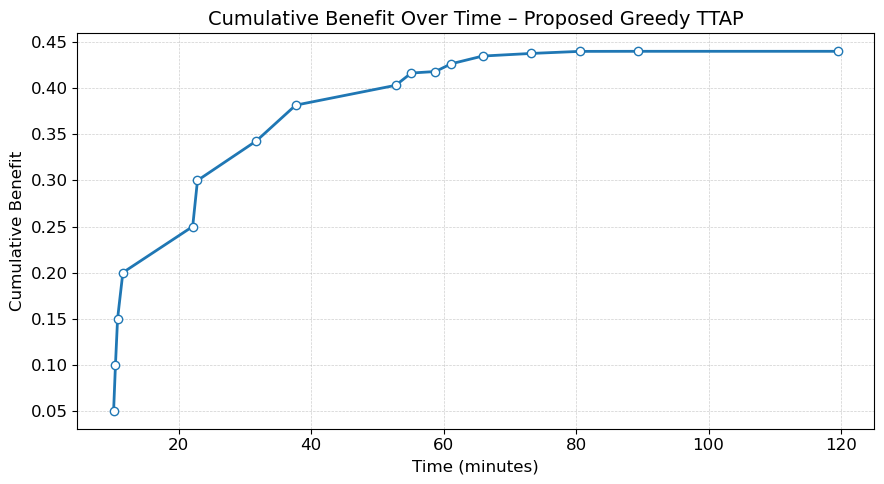

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import pandas as pd

# ------------------------------------------------------------------
SERVICE_TIME = 6
RECOVERY_TIME = 2  

class Node:
    def __init__(self, name, x, y):
        self.name, self.x, self.y = name, x, y
        self.tasks: List[Task] = []

    def add_task(self, task): self.tasks.append(task)
    def distance_to(self, o): return math.hypot(self.x - o.x, self.y - o.y)

class Task:
    def __init__(self, task_id, visual_search, material_transport, medical_assistance,
                 personnel_transfer, optimal_time, effective_time, ineffective_time):
        self.task_id, self.visual_search = task_id, visual_search
        self.material_transport, self.medical_assistance = material_transport, medical_assistance
        self.personnel_transfer = personnel_transfer
        self.optimal_time, self.effective_time, self.ineffective_time = (
            optimal_time, effective_time, ineffective_time)
        self.is_completed, self.completion_time = False, None

    def calculate_benefit(self, t_finish, n_total, alpha=0.1):
        if t_finish <= self.optimal_time:
            f = 1.0
        elif t_finish >= self.ineffective_time:
            f = 0.0
        else:
            f = 1 / (1 + np.exp(alpha * (t_finish - self.effective_time)))
        return f * (1 / n_total)

class Helicopter:
    def __init__(self, hid, hovering, visual_search_capability,
                 load_capacity, medical_capacity, passenger_limit,
                 range_km, speed_kmh, position):
        self.helicopter_id = hid
        self.hovering, self.visual_search_capability = hovering, visual_search_capability
        self.load_capacity, self.medical_capacity = load_capacity, medical_capacity
        self.passenger_limit, self.range_km, self.speed_kmh = passenger_limit, range_km, speed_kmh
        self.position = position
        self.available_time = 0     # inicializado aquí
        self.blocked = False

    def can_complete_task(self, t: Task):
        return ((not t.visual_search or self.visual_search_capability)
                and self.load_capacity >= t.material_transport
                and self.medical_capacity >= t.medical_assistance
                and self.passenger_limit >= t.personnel_transfer)

    def execute_task(self, t: Task, t_finish: float, n_total: int):
        # --- si quieres descontar recursos reales, activa las 3 líneas siguientes
        self.load_capacity   -= t.material_transport
        self.medical_capacity-= t.medical_assistance
        self.passenger_limit -= t.personnel_transfer
        t.is_completed, t.completion_time = True, t_finish
        return t.calculate_benefit(t_finish, n_total)
    
    def return_to_base_and_recover(self, base_node):
        # Tiempo de vuelo de regreso
        tau = self.position.distance_to(base_node) / self.speed_kmh * 60
        self.available_time += tau + RECOVERY_TIME  
        self.position = base_node
        self.load_capacity = 500
        self.medical_capacity = 3
        self.passenger_limit = 3
        return tau, RECOVERY_TIME

# ------------------------------------------------------------------
def initialize_graph():
    """Initialize the rescue graph with nodes, tasks, and helicopters."""
    central_node = Node("Central Base", 0, 0) 
    nodes = [
        central_node,
        Node("Node A", 10, 5),
        Node("Node B", 20, 15),
        Node("Node C", 30, 10),
        Node("Node D", 40, 20)
    ]

    # Add tasks to nodes
    tasks = [
        Task(task_id=1, visual_search=True, material_transport=200, medical_assistance=2, personnel_transfer=1, optimal_time=20, effective_time=40, ineffective_time=60),
        Task(task_id=2, visual_search=False, material_transport=300, medical_assistance=1, personnel_transfer=2, optimal_time=15, effective_time=30, ineffective_time=50),
        Task(task_id=3, visual_search=True, material_transport=100, medical_assistance=3, personnel_transfer=0, optimal_time=10, effective_time=25, ineffective_time=40),
        Task(task_id=4, visual_search=False, material_transport=200, medical_assistance=0, personnel_transfer=3, optimal_time=30, effective_time=50, ineffective_time=70),
        Task(task_id=5, visual_search=True, material_transport=150, medical_assistance=1, personnel_transfer=1, optimal_time=25, effective_time=45, ineffective_time=60),
        Task(task_id=6, visual_search=True, material_transport=100, medical_assistance=3, personnel_transfer=0, optimal_time=10, effective_time=25, ineffective_time=120),
        Task(task_id=7, visual_search=False, material_transport=400, medical_assistance=0, personnel_transfer=3, optimal_time=30, effective_time=50, ineffective_time=90),
        Task(task_id=8, visual_search=True, material_transport=150, medical_assistance=1, personnel_transfer=1, optimal_time=25, effective_time=45, ineffective_time=100),
        Task(task_id=9, visual_search=True, material_transport=200, medical_assistance=2, personnel_transfer=1, optimal_time=20, effective_time=40, ineffective_time=60),
        Task(task_id=10, visual_search=False, material_transport=300, medical_assistance=1, personnel_transfer=2, optimal_time=15, effective_time=30, ineffective_time=50),
        Task(task_id=11, visual_search=True, material_transport=100, medical_assistance=3, personnel_transfer=0, optimal_time=10, effective_time=25, ineffective_time=40),
        Task(task_id=12, visual_search=False, material_transport=200, medical_assistance=0, personnel_transfer=3, optimal_time=30, effective_time=50, ineffective_time=70),
        Task(task_id=13, visual_search=True, material_transport=150, medical_assistance=1, personnel_transfer=1, optimal_time=25, effective_time=45, ineffective_time=60),
        Task(task_id=14, visual_search=True, material_transport=100, medical_assistance=3, personnel_transfer=0, optimal_time=10, effective_time=25, ineffective_time=120),
        Task(task_id=15, visual_search=False, material_transport=400, medical_assistance=0, personnel_transfer=3, optimal_time=30, effective_time=50, ineffective_time=90),
        Task(task_id=16, visual_search=True, material_transport=150, medical_assistance=1, personnel_transfer=1, optimal_time=25, effective_time=45, ineffective_time=100),
        Task(task_id=17, visual_search=True, material_transport=150, medical_assistance=1, personnel_transfer=1, optimal_time=25, effective_time=45, ineffective_time=60),
        Task(task_id=18, visual_search=True, material_transport=100, medical_assistance=3, personnel_transfer=0, optimal_time=10, effective_time=25, ineffective_time=120),
        Task(task_id=19, visual_search=False, material_transport=400, medical_assistance=0, personnel_transfer=3, optimal_time=30, effective_time=50, ineffective_time=90),
        Task(task_id=20, visual_search=True, material_transport=150, medical_assistance=1, personnel_transfer=1, optimal_time=25, effective_time=45, ineffective_time=100),
    ]
    nodes[1].add_task(tasks[0])
    nodes[1].add_task(tasks[1])
    nodes[1].add_task(tasks[8])
    nodes[1].add_task(tasks[9])
    nodes[2].add_task(tasks[2])
    nodes[2].add_task(tasks[7])
    nodes[2].add_task(tasks[6])
    nodes[2].add_task(tasks[10])
    nodes[2].add_task(tasks[11])
    nodes[2].add_task(tasks[12])
    nodes[2].add_task(tasks[13])
    nodes[3].add_task(tasks[4])
    nodes[3].add_task(tasks[5])
    nodes[3].add_task(tasks[14])
    nodes[3].add_task(tasks[15])
    nodes[4].add_task(tasks[3])
    nodes[4].add_task(tasks[16])
    nodes[4].add_task(tasks[17])
    nodes[4].add_task(tasks[18])
    nodes[4].add_task(tasks[19])

    # Define helicopters stationed at the central base
    helicopters = [
        Helicopter(1, hovering=True, visual_search_capability=True, load_capacity=500, medical_capacity=3, passenger_limit=3, range_km=500, speed_kmh=150, position=central_node),
        Helicopter(2, hovering=True, visual_search_capability=False, load_capacity=500, medical_capacity=3, passenger_limit=3, range_km=500, speed_kmh=120, position=central_node),
        Helicopter(3, hovering=True, visual_search_capability=True, load_capacity=500, medical_capacity=3, passenger_limit=3, range_km=500, speed_kmh=140, position=central_node),
        Helicopter(4, hovering=True, visual_search_capability=False, load_capacity=500, medical_capacity=3, passenger_limit=3, range_km=500, speed_kmh=160, position=central_node),
    ]

    return nodes, helicopters

# ------------------------------------------------------------------
def next_available(helicopters):
    active = [h for h in helicopters if not h.blocked]
    return min(active, key=lambda h: h.available_time, default=None)

def simulate(nodes, helicopters, T_max):
    n_total = sum(len(n.tasks) for n in nodes)
    pending, B = n_total, 0.0

    completion_times, individual_benefits = [], []
    capacity_log = []
    
    while pending and (h := next_available(helicopters)) and h.available_time < T_max:
        t_now = h.available_time
        best, best_node, best_benefit, best_tau = None, None, 0, 0

        for n in nodes:
            for task in n.tasks:
                if task.is_completed or not h.can_complete_task(task):
                    continue
                tau = h.position.distance_to(n) / h.speed_kmh * 60
                t_finish = t_now + tau + SERVICE_TIME
                if t_finish >= T_max:
                    continue
                benefit = task.calculate_benefit(t_finish, n_total)
                if benefit > best_benefit:
                    best, best_node = task, n
                    best_benefit, best_tau = benefit, tau

        if best:  # asignar
            h.position = best_node
            h.available_time = t_now + best_tau + SERVICE_TIME
            pending -= 1
            individual_benefits.append(best_benefit)
            completion_times.append(h.available_time)
            benefit = h.execute_task(best, h.available_time, n_total)
            B += benefit
            capacity_log.append({
                "Helo ID": h.helicopter_id,
                "Task ID": best.task_id,
                "Node": best_node.name,
                "Flight Time": best_tau,
                "Service Time": SERVICE_TIME,
                "Total Task Time": best_tau + SERVICE_TIME,
                "Completion Time": h.available_time,
                "Remaining Load": h.load_capacity,
                "Remaining Medical": h.medical_capacity,
                "Remaining Personnel": h.passenger_limit,
                "Status": "Task Executed"
            })
            print(f"H{h.helicopter_id} → T{best.task_id}  fin={h.available_time:.1f}′  ΔB={best_benefit:.3f}")
        else:
            # Si no tiene capacidad, vuelve a base y recarga
            if h.position != nodes[0]:  # Solo si no está en la base
                print(f"H{h.helicopter_id} → Base to recover")
                tau_return, t_recovery = h.return_to_base_and_recover(nodes[0]) 
                capacity_log.append({
                    "Helo ID": h.helicopter_id,
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": tau_return,
                    "Service Time": t_recovery,
                    "Total Task Time": tau_return + t_recovery, 
                    "Completion Time": h.available_time,
                    "Remaining Load": h.load_capacity,
                    "Remaining Medical": h.medical_capacity,
                    "Remaining Personnel": h.passenger_limit,
                    "Status": "Idle"
                })
            else:
                h.blocked = True  # En base y aún no puede hacer nada

    print(f"\n► Tareas completadas: {n_total - pending}/{n_total}")
    print(f"► Beneficio total    : {B:.6f}\n")
    df_capacity = pd.DataFrame(capacity_log, columns=[
        "Helo ID", "Task ID", "Node", "Flight Time", "Service Time", "Total Task Time",
        "Completion Time", "Remaining Load", "Remaining Medical", "Remaining Personnel", "Status"
    ])
    print("\n--- Capacity Usage Log ---")
    print(df_capacity.to_string(index=False))
    
    # --- Análisis de tareas no completadas
    uncompleted_tasks = [t for n in nodes for t in n.tasks if not t.is_completed]

    summary = {
        "Total Uncompleted": len(uncompleted_tasks),
        "Requires Visual Search": 0,
        "Requires Load (Transport)": 0,
        "Requires Medical Assistance": 0,
        "Requires Personnel Transfer": 0,
    }

    for t in uncompleted_tasks:
        if t.visual_search:
            summary["Requires Visual Search"] += 1
        if t.material_transport > 0:
            summary["Requires Load (Transport)"] += 1
        if t.medical_assistance > 0:
            summary["Requires Medical Assistance"] += 1
        if t.personnel_transfer > 0:
            summary["Requires Personnel Transfer"] += 1

    print("\n--- Uncompleted Task Requirements ---")
    for k, v in summary.items():
        print(f"{k}: {v}")
    
    plot_cumulative(completion_times, individual_benefits)
    return df_capacity

def plot_cumulative(times, deltas):
    # Ordenar correctamente
    paired = sorted(zip(times, deltas), key=lambda x: x[0])
    sorted_times, sorted_deltas = zip(*paired)

    # Beneficio acumulado
    cum, y = 0, []
    for d in sorted_deltas:
        cum += d
        y.append(cum)

    # Estilo estético
    plt.figure(figsize=(9, 5))
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 12
    })

    # Curva y puntos
    plt.plot(sorted_times, y, marker='o', markersize=6, 
             markerfacecolor='white', markeredgecolor='#1f77b4', 
             color='#1f77b4', linewidth=2)

    # Ejes y grilla elegante
    plt.xlabel("Time (minutes)")
    plt.ylabel("Cumulative Benefit")
    plt.title("Cumulative Benefit Over Time – Proposed Greedy TTAP", fontsize=14)
    plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.6)

    # Márgenes suaves
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
if __name__ == "__main__":
    nodes, helicopters = initialize_graph()
    df_capacity = simulate(nodes, helicopters, T_max=300)   # 250 min de horizonte
    

## Carta Gantt

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np


def helo_to_int(helo_id):
    """
    Convierte Helo ID a entero:
    1    -> 1
    '1'  -> 1
    'H1' -> 1
    """
    if isinstance(helo_id, str):
        helo_id = helo_id.strip()
        if helo_id.startswith("H"):
            return int(helo_id.replace("H", ""))
        return int(helo_id)
    return int(helo_id)


def normalize_status(status):
    """
    Homologa nombres de estado entre Greedy y Exacto.
    """
    status = str(status)

    if status in ["Task Executed", "Executed"]:
        return "Task Executed"

    if status in ["Idle", "Return + Recovery", "Return", "Base"]:
        return "Return + Recovery"

    return status


def plot_ttap_gantt_like_greedy(
    df,
    title="Gantt Chart – TTAP",
    fixed_service_time=6,
    show_benefit=False,
    xlim=None,
    save_path=None
):
    """
    Gráfico Gantt estilo Greedy TTAP.

    Funciona con:
    - df_capacity del greedy
    - df_solution del exacto v0.1

    Columnas esperadas:
    - Helo ID
    - Task ID
    - Status
    - Flight Time
    - Service Time
    - Completion Time

    Columnas opcionales:
    - Benefit
    """

    # --------------------------------------------------------
    # 1. Preparar datos
    # --------------------------------------------------------
    records = []
    prev_finish = {}

    df_plot = df.copy()

    df_plot["Helo ID"] = df_plot["Helo ID"].apply(helo_to_int)
    df_plot["Status"] = df_plot["Status"].apply(normalize_status)

    df_plot["Flight Time"] = df_plot["Flight Time"].astype(float)
    df_plot["Service Time"] = df_plot["Service Time"].astype(float)
    df_plot["Completion Time"] = df_plot["Completion Time"].astype(float)

    # Ordenar cronológicamente para reconstruir bien cada línea de helicóptero
    df_plot = df_plot.sort_values(
        by=["Completion Time", "Helo ID"]
    ).reset_index(drop=True)

    for _, row in df_plot.iterrows():

        heli = int(row["Helo ID"])
        task = row["Task ID"]
        finish = float(row["Completion Time"])
        service_time = float(row["Service Time"])
        flight_time = float(row["Flight Time"])
        status = row["Status"]

        # Mismo criterio visual del gráfico greedy:
        # el inicio de cada bloque del helicóptero es el término de su actividad previa.
        start = prev_finish.get(heli, 0.0)

        travel = flight_time
        actual_service = service_time

        prev_finish[heli] = finish

        benefit = None
        if "Benefit" in df_plot.columns and pd.notna(row.get("Benefit", np.nan)):
            benefit = float(row["Benefit"])

        records.append({
            "heli": heli,
            "task": task,
            "start": start,
            "travel": travel,
            "service": actual_service,
            "finish": finish,
            "status": status,
            "benefit": benefit,
        })

    if not records:
        print("No hay registros para graficar.")
        return

    # --------------------------------------------------------
    # 2. Graficar
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(18, 5))

    colors = {
        "travel": "#9ecae1",
        "service": "#3182bd",
        "idle": "#cccccc",
    }

    for rec in records:

        y = rec["heli"]

        # -----------------------------
        # Vuelo
        # -----------------------------
        if rec["travel"] > 0:
            ax.broken_barh(
                [(rec["start"], rec["travel"])],
                (y - 0.35, 0.3),
                facecolors=colors["travel"]
            )

        # -----------------------------
        # Servicio o recuperación
        # -----------------------------
        service_start = rec["start"] + rec["travel"]

        if rec["status"] == "Task Executed":
            service_color = colors["service"]
        else:
            service_color = colors["idle"]

        ax.broken_barh(
            [(service_start, rec["service"])],
            (y - 0.35, 0.3),
            facecolors=service_color
        )

        # -----------------------------
        # Etiqueta
        # -----------------------------
        if rec["status"] == "Task Executed":

            if show_benefit and rec["benefit"] is not None:
                label = f"T{rec['task']}\n{rec['benefit']:.3f}"
            else:
                label = f"T{rec['task']}"

            text_color = "white"

        else:
            label = "Base"
            text_color = "black"

        ax.text(
            service_start + rec["service"] / 2,
            y - 0.35 + 0.15,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=8
        )

    # --------------------------------------------------------
    # 3. Formato
    # --------------------------------------------------------
    helos = sorted(set(r["heli"] for r in records))

    ax.set_xlabel("Time (minutes)")
    ax.set_yticks(helos)
    ax.set_yticklabels([f"H{i}" for i in helos])
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.4)
    ax.set_ylim(0.2, max(helos) + 0.8)

    if xlim is not None:
        ax.set_xlim(xlim)

    patches = [
        mpatches.Patch(color=colors["travel"], label="Flight Time"),
        mpatches.Patch(color=colors["service"], label=f"Service Time ({fixed_service_time} min)"),
        mpatches.Patch(color=colors["idle"], label="Recovery/IDLE Time (2 min)")
    ]

    ax.legend(handles=patches, loc="upper right")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

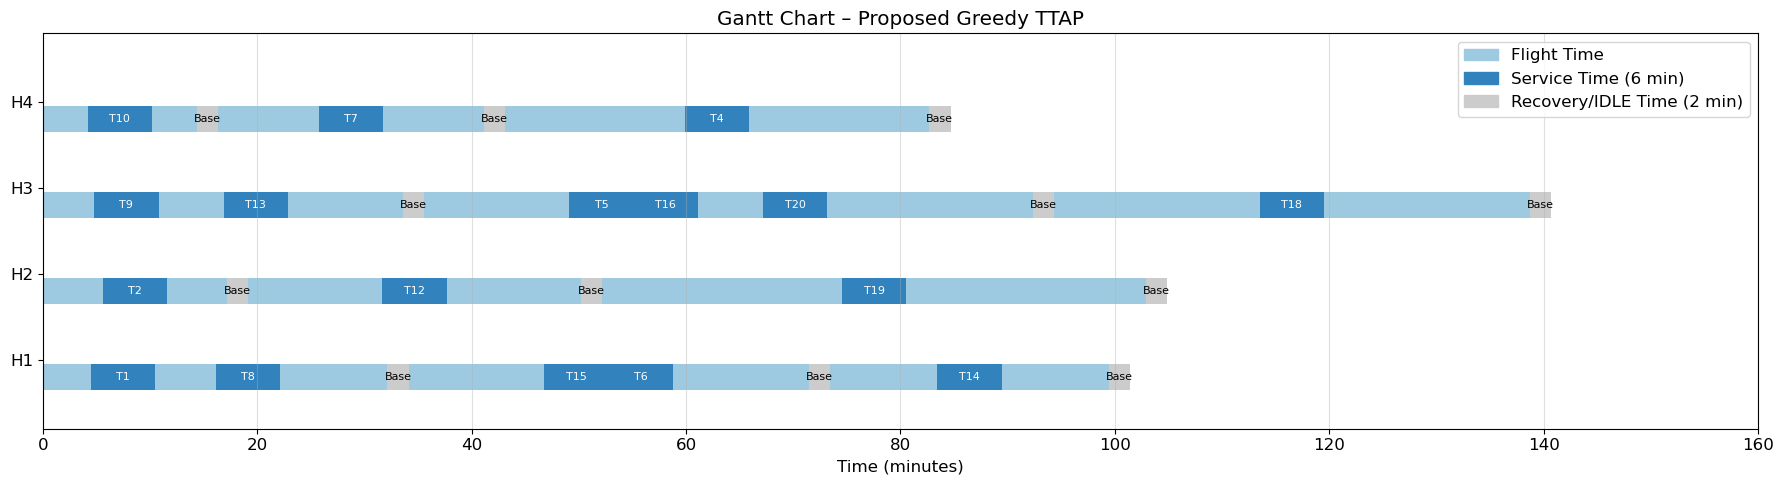

In [8]:
plot_ttap_gantt_like_greedy(
    df_capacity,
    title="Gantt Chart – Proposed Greedy TTAP",
    show_benefit=False,
    xlim=(0, 160),
    save_path="gantt_greedy_ttap.png"
)

## Metrics:

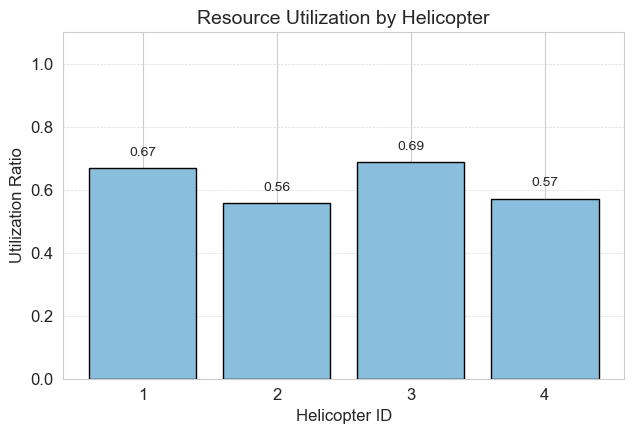

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Metric 1: Response Time (average and max)
response_times = df_capacity[df_capacity["Status"] == "Task Executed"]["Total Task Time"]
avg_response_time = response_times.mean()
max_response_time = response_times.max()

# Metric 2: Task Completion Rate
completed_tasks = df_capacity[df_capacity["Status"] == "Task Executed"].shape[0]
total_tasks = completed_tasks + 3  # assume 3 tasks were uncompleted
task_completion_rate = completed_tasks / total_tasks

# Metric 3: Resource Utilization
resource_utilization = {}
for h in df_capacity["Helo ID"].unique():
    df_h = df_capacity[df_capacity["Helo ID"] == h]
    active_time = df_h[df_h["Status"] == "Task Executed"]["Total Task Time"].sum()
    idle_time = df_h[df_h["Status"] == "Idle"]["Total Task Time"].sum()
    utilization = active_time / (active_time + idle_time) if (active_time + idle_time) > 0 else 0
    resource_utilization[h] = utilization

# Metric 4: Load Balancing (Coefficient of Variation of task count)
task_counts = df_capacity[df_capacity["Status"] == "Task Executed"].groupby("Helo ID").size()
load_balancing_cv = task_counts.std() / task_counts.mean() if not task_counts.empty else 0

# Metric 5: Operational Cost – cumulative flight time
operational_cost = df_capacity["Flight Time"].sum()

# Collect metrics
metrics = {
    "Average Response Time": round(avg_response_time, 2),
    "Max Response Time": round(max_response_time, 2),
    "Task Completion Rate": round(task_completion_rate, 2),
    "Avg Resource Utilization": round(np.mean(list(resource_utilization.values())), 2),
    "Load Balancing (CV)": round(load_balancing_cv, 2),
    "Operational Cost (Flight Time)": round(operational_cost, 2)
}

# Estética general
sns.set_style("whitegrid")

# Crear figura
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Barras con colores elegantes
bars = ax.bar(
    list(resource_utilization.keys()),
    list(resource_utilization.values()),
    color=sns.color_palette("Blues")[2],
    edgecolor='black'
)

# Títulos y etiquetas
ax.set_title("Resource Utilization by Helicopter", fontsize=14)
ax.set_xlabel("Helicopter ID", fontsize=12)
ax.set_ylabel("Utilization Ratio", fontsize=12)
ax.set_xticks([1, 2, 3, 4])
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Etiquetas sobre las barras
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.03,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

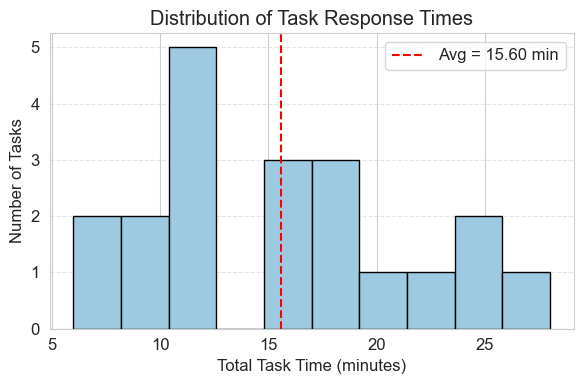

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(response_times, bins=10, color='#9ecae1', edgecolor='black')
plt.axvline(avg_response_time, color='red', linestyle='--', label=f'Avg = {avg_response_time:.2f} min')
plt.xlabel("Total Task Time (minutes)")
plt.ylabel("Number of Tasks")
plt.title("Distribution of Task Response Times")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

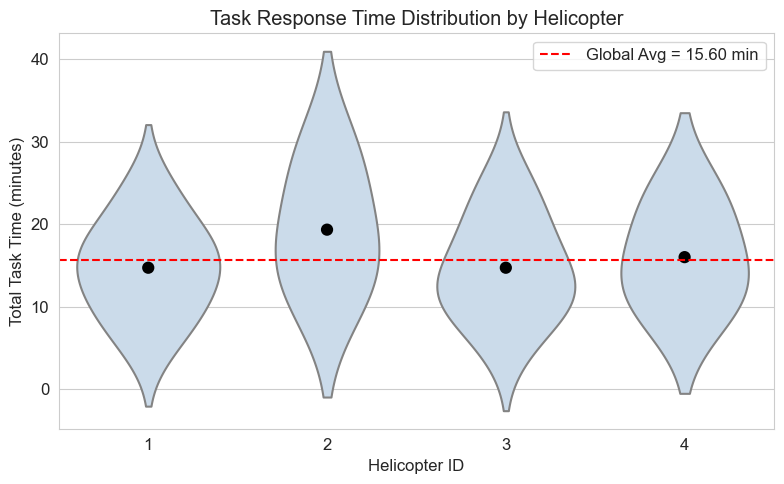

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tasks = df_capacity[df_capacity["Status"] == "Task Executed"]

plt.figure(figsize=(8, 5))

# Violin plot de la distribución
sns.violinplot(x="Helo ID", y="Total Task Time", data=df_tasks, inner=None, color="#c6dbef")

# Medias por helicóptero (puntos negros)
sns.pointplot(x="Helo ID", y="Total Task Time", data=df_tasks,
              estimator='mean', color='black', join=False, markers='o', scale=1.0, errwidth=0)

# Línea de la media global
global_avg = df_tasks["Total Task Time"].mean()
plt.axhline(global_avg, color='red', linestyle='--', label=f'Global Avg = {global_avg:.2f} min')

plt.title("Task Response Time Distribution by Helicopter")
plt.ylabel("Total Task Time (minutes)")
plt.xlabel("Helicopter ID")
plt.legend()
plt.tight_layout()
plt.show()

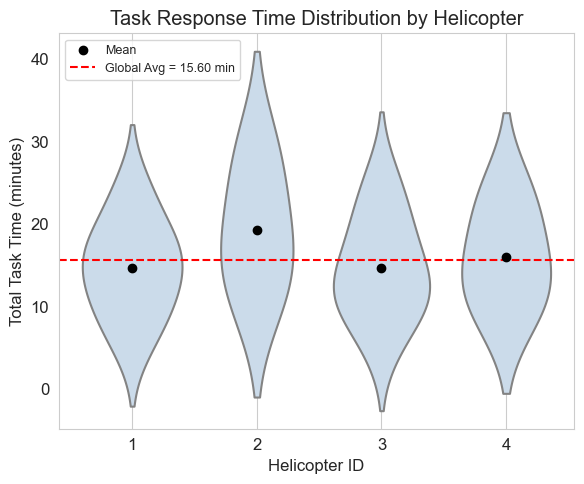

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tasks = df_capacity[df_capacity["Status"] == "Task Executed"]

plt.figure(figsize=(6, 5))
sns.violinplot(x="Helo ID", y="Total Task Time", data=df_tasks, inner=None, color="#c6dbef")

# Media por Helo ID (manual con groupby)
means = df_tasks.groupby("Helo ID")["Total Task Time"].mean()
for idx, (helo, mean_val) in enumerate(means.items()):
    plt.scatter(idx, mean_val, color='black', zorder=10, label="Mean" if idx == 0 else "")

# Línea horizontal: media global
global_avg = df_tasks["Total Task Time"].mean()
plt.axhline(global_avg, color='red', linestyle='--', label=f'Global Avg = {global_avg:.2f} min')

plt.title("Task Response Time Distribution by Helicopter")
plt.ylabel("Total Task Time (minutes)")
plt.xlabel("Helicopter ID")
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.grid()
plt.show()


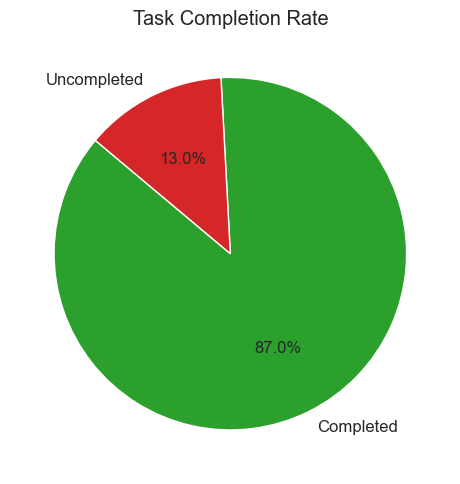

In [8]:
labels = ['Completed', 'Uncompleted']
sizes = [completed_tasks, total_tasks - completed_tasks]
colors = ['#2ca02c', '#d62728']

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, textprops={'fontsize': 12})
plt.title("Task Completion Rate")
plt.tight_layout()
plt.show()

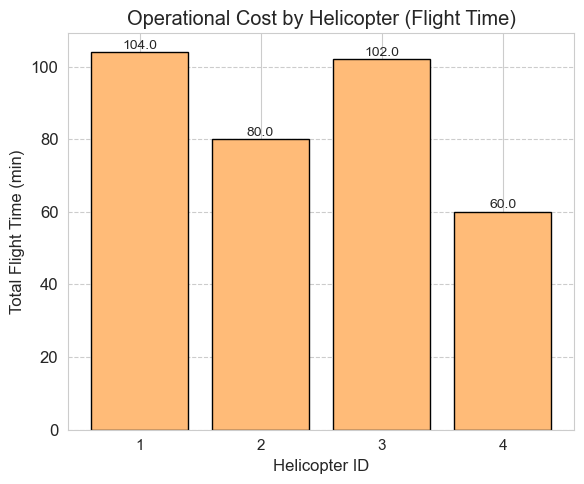

In [9]:
cost_by_helo = df_capacity.groupby("Helo ID")["Flight Time"].sum()

plt.figure(figsize=(6,5))
bars = plt.bar(cost_by_helo.index, cost_by_helo.values, color='#ffbb78', edgecolor='black')
plt.xlabel("Helicopter ID")
plt.xticks(ticks=[1, 2, 3, 4], labels=["1", "2", "3", "4"], fontsize=11)
plt.ylabel("Total Flight Time (min)")
plt.title("Operational Cost by Helicopter (Flight Time)")
plt.grid(axis='y', linestyle='--', alpha=1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

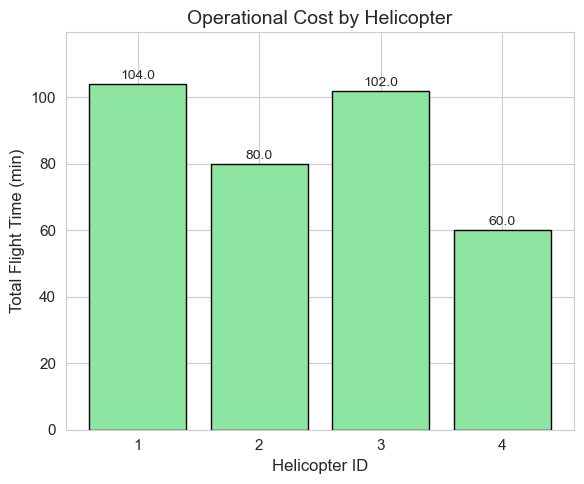

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Datos
cost_by_helo = df_capacity.groupby("Helo ID")["Flight Time"].sum()

# Estética general
plt.figure(figsize=(6, 5))
sns.set_style("whitegrid")

# Plot de barras con colores más neutros
bars = plt.bar(
    cost_by_helo.index.astype(int),  # asegura que el eje x tenga enteros
    cost_by_helo.values,
    color=sns.color_palette("pastel")[2],
    edgecolor='black'
)

# Ejes y título
plt.xlabel("Helicopter ID", fontsize=12)
plt.ylabel("Total Flight Time (min)", fontsize=12)
plt.title("Operational Cost by Helicopter", fontsize=14)
plt.xticks(ticks=[1, 2, 3, 4], labels=["1", "2", "3", "4"], fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, max(cost_by_helo.values) * 1.15)  # margen superior

# Etiquetas sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 1.5,
        f'{height:.1f}',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

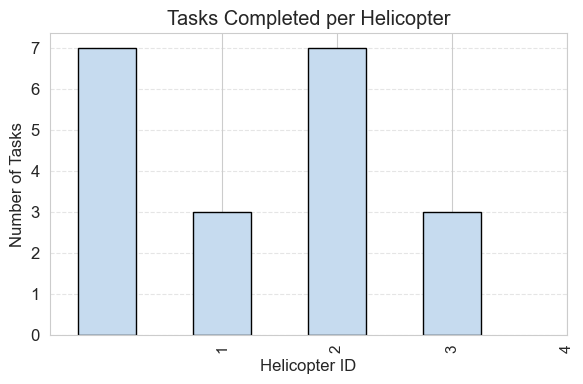

In [11]:
plt.figure(figsize=(6,4))
task_counts.plot(kind='bar', color='#c6dbef', edgecolor='black')
plt.title("Tasks Completed per Helicopter")
plt.xlabel("Helicopter ID")
plt.xticks(ticks=[1, 2, 3, 4], labels=["1", "2", "3", "4"], fontsize=11)
plt.ylabel("Number of Tasks")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

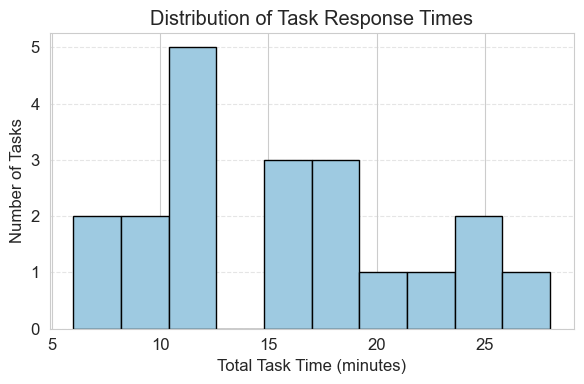

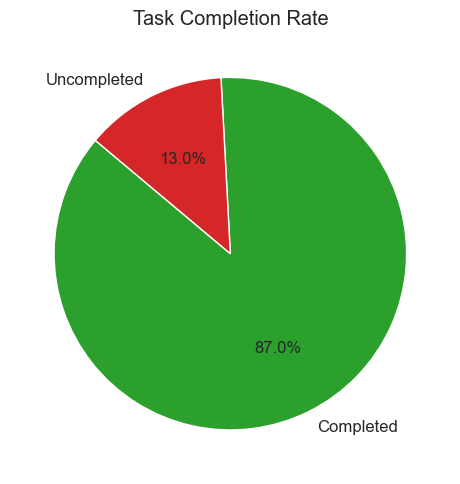

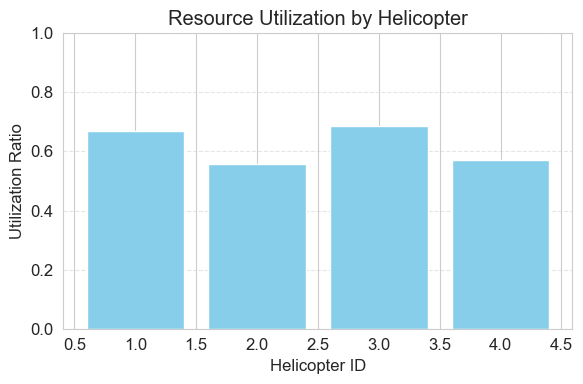

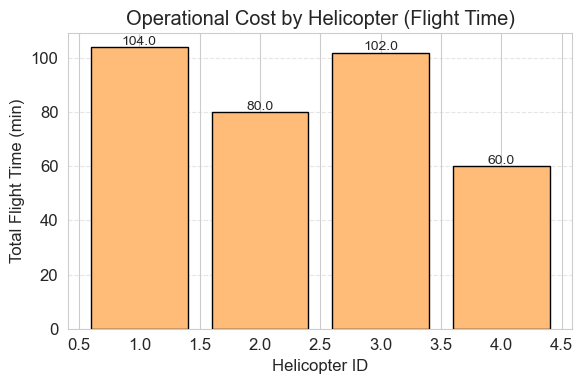

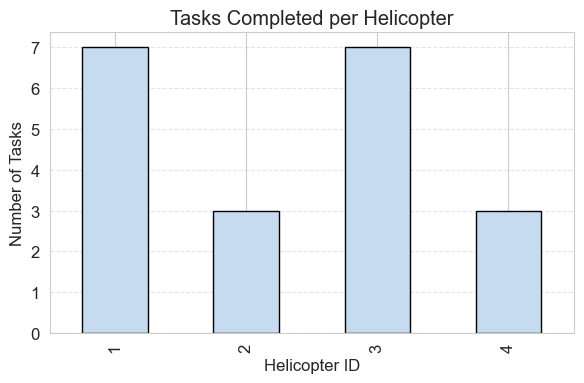

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_performance_metrics(df_capacity: pd.DataFrame, uncompleted_tasks_count: int = 3):
    # ---------------- Metric 1: Response Time ----------------
    response_times = df_capacity[df_capacity["Status"] == "Task Executed"]["Total Task Time"]
    avg_response_time = response_times.mean()
    max_response_time = response_times.max()

    plt.figure(figsize=(6, 4))
    plt.hist(response_times, bins=10, color='#9ecae1', edgecolor='black')
    plt.xlabel("Total Task Time (minutes)")
    plt.ylabel("Number of Tasks")
    plt.title("Distribution of Task Response Times")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ---------------- Metric 2: Task Completion Rate ----------------
    completed_tasks = df_capacity[df_capacity["Status"] == "Task Executed"].shape[0]
    total_tasks = completed_tasks + uncompleted_tasks_count
    sizes = [completed_tasks, total_tasks - completed_tasks]
    labels = ['Completed', 'Uncompleted']
    colors = ['#2ca02c', '#d62728']

    plt.figure(figsize=(5, 5))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 12})
    plt.title("Task Completion Rate")
    plt.tight_layout()
    plt.show()

    # ---------------- Metric 3: Resource Utilization ----------------
    resource_utilization = {}
    for h in df_capacity["Helo ID"].unique():
        df_h = df_capacity[df_capacity["Helo ID"] == h]
        active_time = df_h[df_h["Status"] == "Task Executed"]["Total Task Time"].sum()
        idle_time = df_h[df_h["Status"] == "Idle"]["Total Task Time"].sum()
        utilization = active_time / (active_time + idle_time) if (active_time + idle_time) > 0 else 0
        resource_utilization[h] = utilization

    plt.figure(figsize=(6,4))
    plt.bar(resource_utilization.keys(), resource_utilization.values(), color='skyblue')
    plt.title("Resource Utilization by Helicopter")
    plt.xlabel("Helicopter ID")
    plt.ylabel("Utilization Ratio")
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ---------------- Metric 4: Operational Cost ----------------
    cost_by_helo = df_capacity.groupby("Helo ID")["Flight Time"].sum()

    plt.figure(figsize=(6,4))
    bars = plt.bar(cost_by_helo.index, cost_by_helo.values, color='#ffbb78', edgecolor='black')
    plt.xlabel("Helicopter ID")
    plt.ylabel("Total Flight Time (min)")
    plt.title("Operational Cost by Helicopter (Flight Time)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height:.1f}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # ---------------- Metric 5: Load Balancing ----------------
    task_counts = df_capacity[df_capacity["Status"] == "Task Executed"].groupby("Helo ID").size()

    plt.figure(figsize=(6,4))
    task_counts.plot(kind='bar', color='#c6dbef', edgecolor='black')
    plt.title("Tasks Completed per Helicopter")
    plt.xlabel("Helicopter ID")
    plt.ylabel("Number of Tasks")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Print summary of key metric values
    return {
        "Average Response Time": round(avg_response_time, 2),
        "Max Response Time": round(max_response_time, 2),
        "Task Completion Rate": round(completed_tasks / total_tasks, 2),
        "Avg Resource Utilization": round(sum(resource_utilization.values()) / len(resource_utilization), 2),
        "Load Balancing (CV)": round(task_counts.std() / task_counts.mean(), 2) if not task_counts.empty else 0,
        "Operational Cost (Flight Time)": round(df_capacity["Flight Time"].sum(), 2)
    }

metrics = plot_all_performance_metrics(df_capacity, uncompleted_tasks_count=3)

In [13]:
print(response_times.describe())

count    20.000000
mean     15.600000
std       6.184871
min       6.000000
25%      11.750000
50%      15.500000
75%      19.250000
max      28.000000
Name: Total Task Time, dtype: float64


## Sigmoid Function as a Decay Function

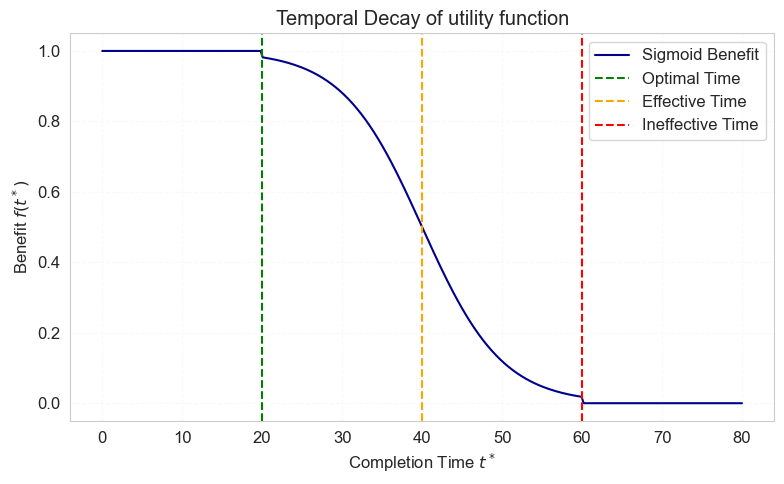

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def corrected_benefit(t, t_optimal, t_effective, t_ineffective, alpha=0.2):
    benefit = []
    for t_ in t:
        if t_ <= t_optimal:
            f = 1
        elif t_ >= t_ineffective:
            f = 0
        else:
            f = 1 / (1 + np.exp(alpha * (t_ - t_effective)))
        benefit.append(f)
    return np.array(benefit)

# Parámetros de prueba
t_opt = 20
t_eff = 40
t_ineff = 60
t_range = np.linspace(0, 80, 300)

# Evaluar y graficar
benefit_values = corrected_benefit(t_range, t_opt, t_eff, t_ineff)

plt.figure(figsize=(8, 5))
plt.plot(t_range, benefit_values, label="Sigmoid Benefit", color="darkblue")
plt.axvline(t_opt, linestyle='--', color='green', label='Optimal Time')
plt.axvline(t_eff, linestyle='--', color='orange', label='Effective Time')
plt.axvline(t_ineff, linestyle='--', color='red', label='Ineffective Time')
plt.title("Temporal Decay of utility function")
plt.xlabel("Completion Time $t^*$")
plt.ylabel("Benefit $f (t^*)$")
plt.grid(True, linestyle="--", alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

## Nodes (gráfico)

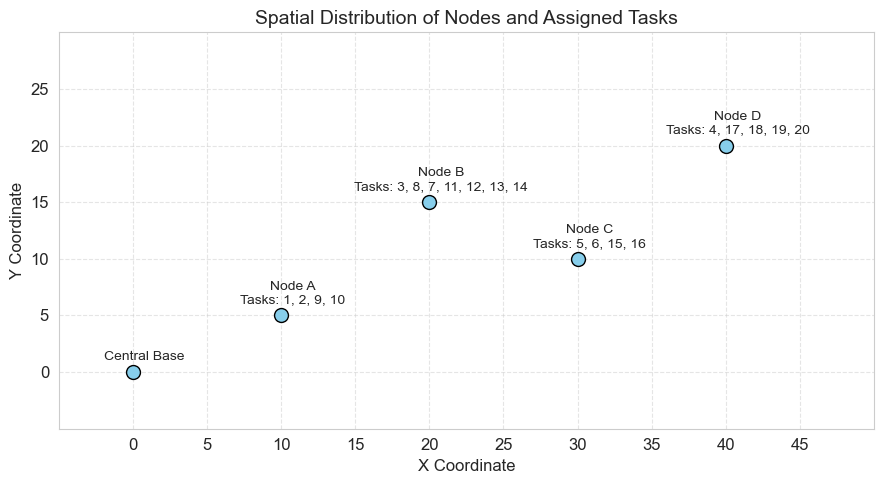

In [15]:
import matplotlib.pyplot as plt

# Coordenadas de los nodos
nodes = {
    "Central Base": (0, 0),
    "Node A": (10, 5),
    "Node B": (20, 15),
    "Node C": (30, 10),
    "Node D": (40, 20)
}

# Asignaciones de tareas por nodo
task_assignments = {
    "Node A": [1, 2, 9, 10],
    "Node B": [3, 8, 7, 11, 12, 13, 14],
    "Node C": [5, 6, 15, 16],
    "Node D": [4, 17, 18, 19, 20]
}

# Crear gráfico
plt.figure(figsize=(9, 5))
for name, (x, y) in nodes.items():
    plt.scatter(x, y, s=100, edgecolors='black', facecolors='skyblue', zorder=3)
    label = f"{name}"
    if name in task_assignments:
        tasks = ', '.join(map(str, task_assignments[name]))
        label += f"\nTasks: {tasks}"
    plt.text(x + 0.8, y + 0.8, label, fontsize=10, ha='center', va='bottom')

# Estética del gráfico
plt.title("Spatial Distribution of Nodes and Assigned Tasks", fontsize=14)
plt.xlabel("X Coordinate", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 50, 5))
plt.yticks(range(0, 30, 5))
plt.xlim(-5, 50)
plt.ylim(-5, 30)
plt.tight_layout()

# Mostrar
plt.show()